<a href="https://www.kaggle.com/code/kubtem/3d-u-net-gan-pipeline?scriptVersionId=247691803" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 3D U‑Net + GAN pipeline

In [ ]:
┌───────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ DYNAMIC AMYLOID PET TO SYNTHETIC FDG-PET GENERATION PIPELINE                                            │
└───────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌───────────────────────┐    ┌─────────────────┐    ┌─────────────────┐    ┌─────────────────┐
│                       │    │                 │    │                 │    │                 │
│   DYNAMIC AMYLOID PET ├───►│   3D U-Net      ├───►│    ST-CNN       ├───►│  SwinUNETR      │
│   (4D: x,y,z + time)  │    │   + GAN         │    │   (Spatio-      │    │  Transformer    │
│                       │    │                 │    │   Temporal)     │    │  Architecture   │
└───────────────────────┘    └───────┬─────────┘    └───────┬─────────┘    └───────┬─────────┘
                                     │                      │                      │
                                     ▼                      ▼                      ▼
┌───────────────────────┐    ┌─────────────────┐    ┌─────────────────┐    ┌─────────────────┐
│                       │    │                 │    │                 │    │                 │
│   GROUND TRUTH        │    │  Discriminator  │    │  Intermediate   │    │  HIGH-QUALITY   │
│   FDG-PET             │◄───┤                 │◄───┤  Enhanced PET   │◄───┤  SYNTHETIC      │
│   (Target)            │    │  (Adversarial   │    │  Volume         │    │  FDG-PET        │
│                       │    │   Training)     │    │                 │    │  (Output)       │
└───────────────────────┘    └─────────────────┘    └─────────────────┘    └─────────────────┘

Detailed Component Breakdown:

1. 3D U-Net + GAN Stage:
   ┌───────────────┐     ┌───────────────┐
   │ 3D Encoder    │     │ 3D Decoder    │
   │ - Downsampling│     │ - Upsampling  │
   │ - 3D Conv     │────►│ - 3D Deconv   │
   │ - BatchNorm   │     │ - Skip Conns  │
   │ - ReLU        │     │ - GAN Refinement
   └───────────────┘     └───────────────┘

2. ST-CNN Stage:
   ┌─────────────────────────────────────┐
   │ Temporal Conv Blocks                │
   │ - 3D Conv + LSTM gates              │
   │ - Residual Connections              │
   │ - Multi-scale Feature Aggregation   │
   └─────────────────────────────────────┘

3. SwinUNETR Stage:
   ┌─────────────────────────────────────┐
   │ 3D Patch Partition                  │
   │ Swin Transformer Blocks             │
   │ - Windowed Self-Attention           │
   │ - Patch Merging/Expansion           │
   │ - Hierarchical Feature Extraction   │
   └─────────────────────────────────────┘

Key Features:
- Blue arrows: Forward data flow
- Red arrows: Adversarial feedback
- All components process 3D volumes with temporal dimension
- Progressive refinement of synthetic FDG-PET quality
- Combines CNN strengths with transformer attention

In [1]:
import torch

# GPU'nun kullanılıp kullanılmadığını kontrol et
print("GPU Kullanılabiliyor mu:", torch.cuda.is_available())

# GPU detaylarını görüntüle
if torch.cuda.is_available():
    print("\nGPU Detayları:")
    print(torch.cuda.get_device_name(0))
else:
    print(" Uyarı: GPU bulunamadı! CPU ile çalışıyor olabilirsiniz.")

# GPU bellek yönetimi için optimizasyon
if torch.cuda.is_available():
    torch.cuda.empty_cache()  # GPU belleğini temizle

# Mixed precision training için (daha hızlı eğitim)
# PyTorch'ta mixed precision training için torch.amp.GradScaler kullanabilirsiniz
scaler = torch.amp.GradScaler()

# GPU bellek kullanımını optimize etmek için
torch.cuda.empty_cache()

# GPU belleğine göre batch size belirleme
BATCH_SIZE = 4  # GPU belleğine göre ayarlayın

GPU Kullanılabiliyor mu: True

GPU Detayları:
Tesla T4


In [2]:
!kaggle competitions quota -c gpu

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.11/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 433, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


# 1. Adım: DICOM Dinamik Veriyi Okuma ve 3D+T Tensor Oluşturma



# Adım 1: Gerekli Kütüphanelerin Yüklenmesi


In [3]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from pydicom.pixel_data_handlers.util import apply_voi_lut
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import time
import warnings


# GAN için ek kütüphaneler
from torchvision.utils import save_image

# Adım 2: Veri Setinin İncelenmesi ve Anlaşılması

In [5]:
import os
import pydicom
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time

# VERİ YOLLARINI DÜZGÜN AYARLAMA
amyloid_path = "/kaggle/input/ano-dyn-ami-fmm"
fdg_path = "/kaggle/input/ano-fdg"

# Hasta klasörlerini listeleme
amyloid_patients = [f for f in os.listdir(amyloid_path) 
                   if os.path.isdir(os.path.join(amyloid_path, f))]
fdg_patients = [f for f in os.listdir(fdg_path) 
               if os.path.isdir(os.path.join(fdg_path, f))]

print("Amyloid Hasta Listesi:", amyloid_patients)
print("FDG-PET Hasta Listesi:", fdg_patients)

def load_dicom_volume(folder_path):
    """Bir hasta klasöründeki tüm DICOM dosyalarını yükler"""
    dicom_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.dcm')]
    slices = []

    for file in dicom_files:
        ds = pydicom.dcmread(file)
        slices.append(ds.pixel_array)

    # Slice'ları sırala (genellikle InstanceNumber'a göre)
    slices.sort(key=lambda x: int(pydicom.dcmread(file).InstanceNumber))

    # 3D volume oluştur
    volume = np.stack(slices)
    return volume

# Örnek bir hasta yükleme (kontrol amaçlı)
sample_amyloid = load_dicom_volume(os.path.join(amyloid_path, amyloid_patients[0]))
sample_fdg = load_dicom_volume(os.path.join(fdg_path, fdg_patients[0]))

print("\nAmyloid örnek boyut:", sample_amyloid.shape)
print("FDG örnek boyut:", sample_fdg.shape)

# Tüm verileri yükleme
amyloid_volumes = []
fdg_volumes = []

for patient in amyloid_patients:
    path = os.path.join(amyloid_path, patient)
    volume = load_dicom_volume(path)
    amyloid_volumes.append(volume)

for patient in fdg_patients:
    path = os.path.join(fdg_path, patient)
    volume = load_dicom_volume(path)
    fdg_volumes.append(volume)

# NumPy array'e çevirme
amyloid_volumes = np.array(amyloid_volumes)
fdg_volumes = np.array(fdg_volumes)

print("\nAmyloid veri boyutu:", amyloid_volumes.shape)
print("FDG veri boyutu:", fdg_volumes.shape)

Amyloid Hasta Listesi: ['FMM_70593011_PT_2025-05-07_140149_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_71238102_PT_2025-06-18_144142_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_59021679_PT_2025-03-26_143140_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_71005819_PT_2025-03-26_141550_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_71198117_PT_2025-03-12_140703_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_51015944_PT_2025-02-12_144127_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_16465528_PT_2025-04-17_085826_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_59021808_PT_2025-06-04_132416_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_70698802_PT_2025-05-28_135110_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_70703196_PT_2025-05-14_150417_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_51126284_PT_2025-06-18_155813_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_71217052_PT_2025-04-17_084513_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_59013459_PT_2025-04-09_141856_Tomos_DYN.1_n2142__00000', 'FMM_70446033_PT_2025-06-11_144352_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_51053094_PT_

In [6]:
# Amyloid PET klasör yapısını inceleme
amyloid_path = "/kaggle/input/ano-dyn-ami-fmm"
amyloid_patients = os.listdir(amyloid_path)
print("Amyloid PET Hasta Sayısı:", len(amyloid_patients))
print("Amyloid PET Hasta Listesi:", amyloid_patients)

# FDG-PET klasör yapısını inceleme
fdg_path = "/kaggle/input/ano-fdg"
fdg_patients = os.listdir(fdg_path)
print("\nFDG-PET Hasta Sayısı:", len(fdg_patients))
print("FDG-PET Hasta Listesi:", fdg_patients)

Amyloid PET Hasta Sayısı: 18
Amyloid PET Hasta Listesi: ['FMM_70593011_PT_2025-05-07_140149_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_71238102_PT_2025-06-18_144142_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_59021679_PT_2025-03-26_143140_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_71005819_PT_2025-03-26_141550_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_71198117_PT_2025-03-12_140703_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_51015944_PT_2025-02-12_144127_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_16465528_PT_2025-04-17_085826_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_59021808_PT_2025-06-04_132416_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_70698802_PT_2025-05-28_135110_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_70703196_PT_2025-05-14_150417_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_51126284_PT_2025-06-18_155813_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_71217052_PT_2025-04-17_084513_Tomos_DYN.14X30SEC_n2142__00000', 'FMM_59013459_PT_2025-04-09_141856_Tomos_DYN.1_n2142__00000', 'FMM_70446033_PT_2025-06-11_144352_Tomos_DYN.14X30SEC

Toplam Amyloid PET dosya sayısı: 38556
Toplam FDG-PET dosya sayısı: 7497

DICOM File Information:
Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 182
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Positron Emission Tomography Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.840.113619.2.492.497828346.1746620058.758912
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 2.16.840.1.114362.1
(0002,0013) Implementation Version Name         SH: 'MIM737O60601'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 192'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY']
(0008,0012) Instance Creation Date              DA: '20250507'
(0008,0013) Instance Creation Time              TM: '141418'
(000

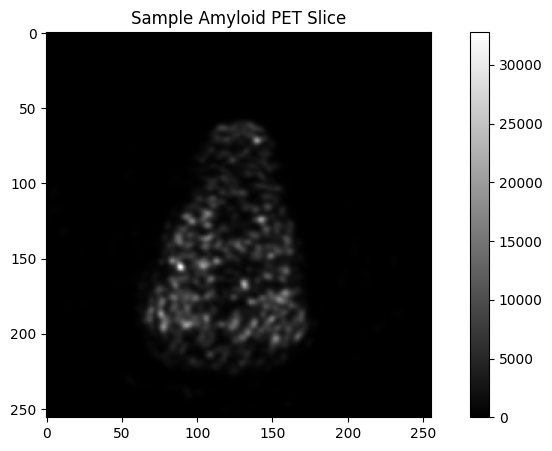

In [7]:
# Dizin yapılarını inceleyelim
amyloid_dir = '/kaggle/input/ano-dyn-ami-fmm'
fdg_dir = '/kaggle/input/ano-fdg'

# Amyloid PET dosyalarını listeleme
amyloid_files = []
for root, dirs, files in os.walk(amyloid_dir):
    for file in files:
        if file.endswith('.dcm'):
            amyloid_files.append(os.path.join(root, file))

# FDG-PET dosyalarını listeleme
fdg_files = []
for root, dirs, files in os.walk(fdg_dir):
    for file in files:
        if file.endswith('.dcm'):
            fdg_files.append(os.path.join(root, file))

print(f"Toplam Amyloid PET dosya sayısı: {len(amyloid_files)}")
print(f"Toplam FDG-PET dosya sayısı: {len(fdg_files)}")

# İlk dosyayı inceleyelim
sample_dcm = pydicom.dcmread(amyloid_files[0])
print("\nDICOM File Information:")
print(sample_dcm)

# Pixel verilerini alalım
pixel_data = apply_voi_lut(sample_dcm.pixel_array, sample_dcm)
print("\nPixel Data Shape:", pixel_data.shape)
print("Pixel Data Type:", pixel_data.dtype)
print("Pixel Data Min/Max:", pixel_data.min(), pixel_data.max())

# Görselleştirme
plt.figure(figsize=(10, 5))
plt.imshow(pixel_data, cmap='gray')
plt.title("Sample Amyloid PET Slice")
plt.colorbar()
plt.show()

# DATA ANONIM CONTROL

In [8]:
# DATA ANONIM CONTROL
import os
import pydicom

# Dizin yolları
amyloid_path = "/kaggle/input/ano-dyn-ami-fmm"
fdg_path = "/kaggle/input/ano-fdg"

# Hangi DICOM tag'lerinde kişisel bilgi olabilir (PHI listesi)
phi_tags = [
    "PatientName",
    "PatientID",
    "PatientBirthDate",
    "PatientSex",
    "OtherPatientIDs",
    "OtherPatientNames",
    "InstitutionName",
    "ReferringPhysicianName",
]

def check_phi_in_folder(folder_path):
    print(f"\n🔎 Kontrol edilen klasör: {folder_path}")
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".dcm"):
                filepath = os.path.join(root, file)
                try:
                    dcm = pydicom.dcmread(filepath, stop_before_pixels=True)
                    print(f"\n📁 Dosya: {file}")
                    for tag in phi_tags:
                        if hasattr(dcm, tag):
                            value = getattr(dcm, tag)
                            if value not in ["", None]:
                                print(f"⚠️ {tag}: {value}")
                    break  # Sadece 1 dosya örneğini göster
                except Exception as e:
                    print(f"Hata: {file} okunamadı. {e}")
                break  # Sadece ilk dosya örneği yeterli

# Amyloid PET dosyaları için kontrol
check_phi_in_folder(amyloid_path)

# FDG PET dosyaları için kontrol
check_phi_in_folder(fdg_path)


🔎 Kontrol edilen klasör: /kaggle/input/ano-dyn-ami-fmm

📁 Dosya: 1.2.840.113619.2.492.497828346.1746620058.758912.dcm
⚠️ PatientName: CITRO^GERARDO
⚠️ PatientID: 70593011
⚠️ PatientBirthDate: 19460202
⚠️ PatientSex: M
⚠️ OtherPatientIDs: CTRGRD46B02G834C
⚠️ InstitutionName: Ospedale San Raffaele

📁 Dosya: 1.2.840.113619.2.492.497828346.1750251557.521267.dcm
⚠️ PatientName: PALAGI^LUCIA
⚠️ PatientID: 71238102
⚠️ PatientBirthDate: 19731205
⚠️ PatientSex: F
⚠️ OtherPatientIDs: PLGLCU73T45D612K
⚠️ InstitutionName: Ospedale San Raffaele

📁 Dosya: 1.2.840.113619.2.492.497828346.1742996788.49155.dcm
⚠️ PatientName: ARIVELLA^ANNA MARIA
⚠️ PatientID: 59021679
⚠️ PatientBirthDate: 19640118
⚠️ PatientSex: F
⚠️ OtherPatientIDs: RVLNMR64A58L483E
⚠️ InstitutionName: Ospedale San Raffaele

📁 Dosya: 1.2.840.113619.2.492.497828346.1742995638.354242.dcm
⚠️ PatientName: PELLEGRINI^MARCO ETTORE
⚠️ PatientID: 71005819
⚠️ PatientBirthDate: 19650821
⚠️ PatientSex: M
⚠️ OtherPatientIDs: 260HX022
⚠️ Instituti

In [9]:
# DATA ANONIM YAPMA
import os
import pydicom
from pydicom.uid import generate_uid
import shutil
import zipfile

# Kaynak klasörler (Kaggle'daki yüklediğin dizinler)
amyloid_path = "/kaggle/input/ano-dyn-ami-fmm"
fdg_path = "/kaggle/input/ano-fdg"

# Hedef (anonimleştirilmiş) klasörler
anon_amyloid = "/kaggle/working/anon_amyloid"
anon_fdg = "/kaggle/working/anon_fdg"

# Klasör oluştur (varsa temizle)
for folder in [anon_amyloid, anon_fdg]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# Anonimleştirme fonksiyonu
def anonymize_dicom_file(input_path, output_path):
    ds = pydicom.dcmread(input_path)
    
    # Kişisel bilgileri temizle
    ds.PatientName = "Anon"
    ds.PatientID = "000000"
    ds.PatientBirthDate = ""
    ds.PatientSex = ""
    ds.InstitutionName = ""
    ds.ReferringPhysicianName = ""
    
    # UID'leri yenile (güvenli olur)
    ds.StudyInstanceUID = generate_uid()
    ds.SeriesInstanceUID = generate_uid()
    ds.SOPInstanceUID = generate_uid()
    
    # Özel tag’leri sil
    ds.remove_private_tags()
    
    # Yeni dosyayı kaydet
    ds.save_as(output_path)

# Bir klasördeki tüm DICOM dosyalarını anonimleştir
def anonymize_folder(src_folder, dst_folder):
    for root, dirs, files in os.walk(src_folder):
        for file in files:
            if file.endswith(".dcm"):
                in_path = os.path.join(root, file)
                out_path = os.path.join(dst_folder, file)
                try:
                    anonymize_dicom_file(in_path, out_path)
                    print(f"✅ {file} anonimleştirildi")
                except Exception as e:
                    print(f"❌ Hata: {file} - {e}")

# Uygula
print("\n--- Amyloid dosyaları anonimleştiriliyor ---")
anonymize_folder(amyloid_path, anon_amyloid)

print("\n--- FDG dosyaları anonimleştiriliyor ---")
anonymize_folder(fdg_path, anon_fdg)

# Anonimleştirilmiş klasörleri zipleyelim
def zip_folder(folder_path, zip_path):
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                abs_path = os.path.join(root, file)
                rel_path = os.path.relpath(abs_path, folder_path)
                zipf.write(abs_path, rel_path)

# ZIP dosyaları oluştur
zip_folder(anon_amyloid, "/kaggle/working/anon_amyloid.zip")
zip_folder(anon_fdg, "/kaggle/working/anon_fdg.zip")

print("\n✅ ZIP dosyaları hazır: `anon_amyloid.zip` ve `anon_fdg.zip` Kaggle'dan indirilebilir.")


--- Amyloid dosyaları anonimleştiriliyor ---
✅ 1.2.840.113619.2.492.497828346.1746620058.758912.dcm anonimleştirildi
✅ 1.2.840.113619.2.492.497828346.1746620068.573925.dcm anonimleştirildi
✅ 1.2.840.113619.2.492.497828346.1746620040.530976.dcm anonimleştirildi
✅ 1.2.840.113619.2.492.497828346.1746620004.273830.dcm anonimleştirildi
✅ 1.2.840.113619.2.492.497828346.1746620019.60165.dcm anonimleştirildi
✅ 1.2.840.113619.2.492.497828346.1746619998.314177.dcm anonimleştirildi
✅ 1.2.840.113619.2.492.497828346.1746620087.751092.dcm anonimleştirildi
✅ 1.2.840.113619.2.492.497828346.1746620003.444906.dcm anonimleştirildi
✅ 1.2.840.113619.2.492.497828346.1746620059.623214.dcm anonimleştirildi
✅ 1.2.840.113619.2.492.497828346.1746620068.722835.dcm anonimleştirildi
✅ 1.2.840.113619.2.492.497828346.1746620003.367480.dcm anonimleştirildi
✅ 1.2.840.113619.2.492.497828346.1746620035.348133.dcm anonimleştirildi
✅ 1.2.840.113619.2.492.497828346.1746620088.20273.dcm anonimleştirildi
✅ 1.2.840.113619.2.4

# Adım 3: Veri Ön İşleme ve Dataset Sınıfı Oluşturma

In [ ]:
class MedicalImageDataset(Dataset):
    def __init__(self, amyloid_path, fdg_path):
        self.amyloid_path = amyloid_path
        self.fdg_path = fdg_path
# bunu sildik self.transform = transform

    def __len__(self):
        return len(self.amyloid_path)

    def __getitem__(self, idx):
        # Amyloid PET görüntüsünü yükle
        amyloid_dcm = pydicom.dcmread(self.amyloid_path[idx])
        amyloid_img = apply_voi_lut(amyloid_dcm.pixel_array, amyloid_dcm)


        
        # FDG-PET görüntüsünü yükle
        fdg_dcm = pydicom.dcmread(self.fdg_path[idx])
        fdg_img = apply_voi_lut(fdg_dcm.pixel_array, fdg_dcm)

        # Görüntüleri normalize et [0, 1] aralığına
        def normalize_image(image):
            img_min = image.min()
            img_max = image.max()

            # Eğer maksimum ve minimum değerler aynıysa, sıfır bölme hatasını önle
            if img_max - img_min == 0:
                return np.zeros_like(image)

            # Normalize işlemi
            return (image - img_min) / (img_max - img_min)

        amyloid_img = normalize_image(amyloid_img)
        fdg_img = normalize_image(fdg_img)

        # Görüntüleri tensöre çevir ve boyut ekle [C, H, W]
        amyloid_img = torch.FloatTensor(amyloid_img).unsqueeze(0)  # [1, D, H, W]
        fdg_img = torch.FloatTensor(fdg_img).unsqueeze(0)  # [1, D, H, W]

        # 3D U-Net için boyut ekle [C, D, H, W] - D (depth) boyutunu 1 yapıyoruz
        amyloid_img = amyloid_img.unsqueeze(0)  # [1, 1, H, W]
        fdg_img = fdg_img.unsqueeze(0)  # [1, 1, H, W]

        return amyloid_img, fdg_img



# Veri setini oluşturalım
dataset = MedicalImageDataset(amyloid_files, fdg_files)

# Veri setini eğitim ve test olarak ayıralım
train_files, test_files = train_test_split(list(zip(amyloid_files, fdg_files)), test_size=0.2, random_state=42)
train_amyloid, train_fdg = zip(*train_files)
test_amyloid, test_fdg = zip(*test_files)

train_dataset = MedicalImageDataset(train_amyloid, train_fdg)
test_dataset = MedicalImageDataset(test_amyloid, test_fdg)


# DataLoader'ları oluşturalım
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=4)

print(f"Eğitim örnek sayısı: {len(train_dataset)}")
print(f"Test örnek sayısı: {len(test_dataset)}")

# Adım 4: ***3D*** U-Net Modeli Oluşturma

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv3D(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down3D(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool3d(2),
            DoubleConv3D(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up3D(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose3d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)

        self.conv = DoubleConv3D(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diffD = x2.size()[2] - x1.size()[2]
        diffH = x2.size()[3] - x1.size()[3]
        diffW = x2.size()[4] - x1.size()[4]

        x1 = F.pad(x1, [diffW // 2, diffW - diffW // 2,
                        diffH // 2, diffH - diffH // 2,
                        diffD // 2, diffD - diffD // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv3D, self).__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet3D(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(UNet3D, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv3D(n_channels, 64)
        self.down1 = Down3D(64, 128)
        self.down2 = Down3D(128, 256)
        self.down3 = Down3D(256, 512)
        self.down4 = Down3D(512, 1024)
        self.up1 = Up3D(1024, 512, bilinear)
        self.up2 = Up3D(512, 256, bilinear)
        self.up3 = Up3D(256, 128, bilinear)
        self.up4 = Up3D(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)


    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

# Modeli oluşturalım
device = torch.device('cuda' if torch.cuda.is_available() else 'gpu')
model = UNet3D(n_channels=1, n_classes=1).to(device)
print(model)


# Adım 5: Model Eğitimi

In [ ]:

# Kayıp fonksiyonu ve optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Eğitim fonksiyonu
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=25):
    since = time.time()
    
    train_loss_history = []
    test_loss_history = []
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)
        
        # Her epoch için eğitim ve validasyon aşaması
        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()  # Modeli eğitim moduna al
                dataloader = train_loader
            else:
                model.eval()   # Modeli değerlendirme moduna al
                dataloader = test_loader
            
            running_loss = 0.0
            
            # Veriler üzerinde iterate
            for inputs, labels in tqdm(dataloader): #tqdm burada fazlaLIKMI BAK
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Sıfır gradient
                optimizer.zero_grad()
                
                # Forward
                # Sadece eğitim sırasında track history
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    
                    # Eğitim sırasında backward + optimize
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # İstatistikler
                running_loss += loss.item() * inputs.size(0)
            
            epoch_loss = running_loss / len(dataloader.dataset)
            
            if phase == 'train':
                train_loss_history.append(epoch_loss)
            else:
                test_loss_history.append(epoch_loss)
            
            print(f'{phase} Loss: {epoch_loss:.4f}')
    
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    
    return model, train_loss_history, test_loss_history

# Modeli eğitelim
num_epochs = 50
model, train_loss, test_loss = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs)


# Kayıp grafiğini çiz
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(test_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
#KONTROL
# Veri setindeki görüntülerin boyutlarını kontrol etme
for i, (inputs, labels) in enumerate(train_loader):
    print(f"Batch {i+1}:")
    print(f"  Input shape: {inputs.shape}")
    print(f"  Label shape: {labels.shape}")
    if i == 0:  # Sadece ilk batch'i kontrol etmek için
        break


In [ ]:
#kontrol

# Modelin katmanlarındaki boyut değişikliklerini kontrol etme
model = UNet3D(n_channels=1, n_classes=1).to(device)

# Örnek bir girdi oluşturma (örnek olarak, 1x64x256x256 boyutunda bir girdi)
example_input = torch.randn(1, 1, 64, 256, 256).to(device)  # (batch_size, channels, depth, height, width)

# Modeldeki her katmandan geçerek çıkış boyutlarını izleme
x = example_input
print(f"Input shape: {x.shape}")

x = model.inc(x)
print(f"After inc: {x.shape}")

x = model.down1(x)
print(f"After down1: {x.shape}")

x = model.down2(x)
print(f"After down2: {x.shape}")

x = model.down3(x)
print(f"After down3: {x.shape}")

x = model.down4(x)
print(f"After down4: {x.shape}")

x = model.up1(x, x)  # Bu sadece bir örnek, gerçekte x2, x3 gibi değişkenler kullanılmalı
print(f"After up1: {x.shape}")

x = model.up2(x, x)  # Bu sadece bir örnek, gerçekte x2, x3 gibi değişkenler kullanılmalı
print(f"After up2: {x.shape}")

x = model.up3(x, x)  # Bu sadece bir örnek, gerçekte x2, x3 gibi değişkenler kullanılmalı
print(f"After up3: {x.shape}")

x = model.up4(x, x)  # Bu sadece bir örnek, gerçekte x2, x3 gibi değişkenler kullanılmalı
print(f"After up4: {x.shape}")

x = model.outc(x)
print(f"After outc: {x.shape}")


In [ ]:
#kontrol
import pydicom
from pathlib import Path

def get_image_dimensions(directory_path):
    dimensions = []

    # Dizin içindeki tüm DICOM dosyaları üzerinde döngü yapın
    for file_path in Path(directory_path).rglob('*'):
        try:
            # DICOM dosyasını okuyun
            ds = pydicom.dcmread(file_path)

            # Görüntünün boyutlarını alın
            dimensions.append(ds.pixel_array.shape)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    return dimensions

# Kullanım örneği:
# amiloid_dimensions = get_image_dimensions("path_to_amiloid_pet_directory")
# fdg_dimensions = get_image_dimensions("path_to_fdg_pet_directory")

# Lütfen \"path_to_amiloid_pet_directory\" ve \"path_to_fdg_pet_directory\" yerlerini, DICOM dosyalarınızın bulunduğu gerçek dizin yollarıyla değiştirin.

# Kodu çalıştırdıktan sonra, `amiloid_dimensions` ve `fdg_dimensions` çıktılarını benimle paylaşabilirsiniz.

# Örnek çıktı formatı:
# amiloid_dimensions = [(height1, width1), (height2, width2), ...]
# fdg_dimensions = [(height1, width1), (height2, width2), ...]


# Adım 6: Model Değerlendirme ve Görselleştirme

In [ ]:
import torch
import matplotlib.pyplot as plt

# Test setinde modeli değerlendirelim
model.eval()
with torch.no_grad():
    # Bir batch test verisi al
    test_inputs, test_labels = next(iter(test_loader))
    test_inputs = test_inputs.to(device)
    test_labels = test_labels.to(device)

    # Hedef tensörlerinin boyutunu giriş tensörlerinin boyutuna uyacak şekilde ayarla
    test_labels = test_labels.squeeze(dim=2)

    # Tahmin yap
    test_outputs = model(test_inputs)

    # Girdi, gerçek ve tahmin edilen görüntüleri görselleştir
    fig, axes = plt.subplots(3, 4, figsize=(15, 10))

    for i in range(20):  # İlk 4 örneği göster
        # Girdi (Amyloid PET)
        axes[0, i].imshow(test_inputs[i, 0].cpu().numpy().squeeze(), cmap='gray')
        axes[0, i].set_title(f'Amyloid PET {i+1}')
        axes[0, i].axis('off')

        # Gerçek FDG-PET
        axes[1, i].imshow(test_labels[i, 0].cpu().numpy().squeeze(), cmap='gray')
        axes[1, i].set_title(f'Real FDG-PET {i+1}')
        axes[1, i].axis('off')

        # Tahmin edilen FDG-PET
        axes[2, i].imshow(test_outputs[i, 0].cpu().numpy().squeeze(), cmap='gray')
        axes[2, i].set_title(f'Predicted FDG-PET {i+1}')
        axes[2, i].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
##deneme
import matplotlib.pyplot as plt

# Test setinde modeli değerlendirelim
model.eval()
with torch.no_grad():
    # Bir batch test verisi al
    test_inputs, test_labels = next(iter(test_loader))
    test_inputs = test_inputs.to(device)
    test_labels = test_labels.to(device)

    # Hedef tensörlerinin boyutunu giriş tensörlerinin boyutuna uyacak şekilde ayarla
    test_labels = test_labels.squeeze(dim=2)

    # Tahmin yap
    test_outputs = model(test_inputs)

    # Girdi, gerçek ve tahmin edilen görüntüleri görselleştir
    fig, axes = plt.subplots(3, 4, figsize=(15, 10))

    for i in range(4):  # İlk 4 örneği göster
        # Girdi (Amyloid PET)
        axes[0, i].imshow(test_inputs[i, 0].cpu().numpy().squeeze(), cmap='gray')
        axes[0, i].set_title(f'Amyloid PET {i+1}')
        axes[0, i].axis('off')

        # Gerçek FDG-PET
        axes[1, i].imshow(test_labels[i, 0].cpu().numpy().squeeze(), cmap='gray')
        axes[1, i].set_title(f'Real FDG-PET {i+1}')
        axes[1, i].axis('off')

        # Tahmin edilen FDG-PET
        axes[2, i].imshow(test_outputs[i, 0].cpu().numpy().squeeze(), cmap='gray')
        axes[2, i].set_title(f'Predicted FDG-PET {i+1}')
        axes[2, i].axis('off')

    plt.tight_layout()
    plt.show()


# Adım 7: GAN ile Geliştirme (3D U-Net + GAN)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet3D(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(UNet3D, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        # Encoder
        self.encoder1 = self.contracting_block(n_channels, 64)
        self.encoder2 = self.contracting_block(64, 128)
        self.encoder3 = self.contracting_block(128, 256)
        self.encoder4 = self.contracting_block(256, 512)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv3d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm3d(1024),
            nn.ReLU(inplace=True),
            nn.Conv3d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm3d(1024),
            nn.ReLU(inplace=True),
            nn.ConvTranspose3d(1024, 512, kernel_size=2, stride=2)  # Çıktı kanallarını 512 olarak ayarlayın
        )

        # Decoder
        self.decoder4 = self.expansive_block(1024, 512)  # Giriş kanallarını 1024 olarak ayarlayın
        self.decoder3 = self.expansive_block(512, 256)
        self.decoder2 = self.expansive_block(256, 128)
        self.decoder1 = self.expansive_block(128, 64)

        # Final convolution
        self.final_conv = nn.Conv3d(64, n_classes, kernel_size=1)

    def contracting_block(self, in_channels, out_channels):
        block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2, stride=2, padding=1)
        )
        return block

    def expansive_block(self, in_channels, out_channels):
        block = nn.Sequential(
            nn.ConvTranspose3d(in_channels, out_channels, kernel_size=2, stride=2),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )
        return block

    def forward(self, x):
        # Encoder 
        e1 = self.encoder1(x)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)

        # Bottleneck
        b = self.bottleneck(e4)

        # Decoder
        d4 = self.decoder4(torch.cat([b, e4], dim=1))
        d3 = self.decoder3(torch.cat([d4, e3], dim=1))
        d2 = self.decoder2(torch.cat([d3, e2], dim=1))
        d1 = self.decoder1(torch.cat([d2, e1], dim=1))

        # Final convolution
        out = self.final_conv(d1)
        return out

# Discriminator modeli
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv3d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv3d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv3d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv3d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv3d(512, 1, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# GAN için hyperparameters
lr = 0.0002
b1 = 0.5
b2 = 0.999
n_epochs = 100
sample_interval = 400

# Initialize generator and discriminator
generator = UNet3D(n_channels=1, n_classes=1).to(device)
discriminator = Discriminator().to(device)

# Loss function
adversarial_loss = nn.BCELoss()
pixelwise_loss = nn.L1Loss()

# Optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))

# GAN eğitim döngüsü
for epoch in range(n_epochs):
    for i, (imgs, labels) in enumerate(train_loader):

        # Gerçek ve sahte etiketler
        valid = torch.ones((imgs.size(0), 1, 1, 1, 1), requires_grad=False).to(device)
        fake = torch.zeros((imgs.size(0), 1, 1, 1, 1), requires_grad=False).to(device)

        # Gerçek görüntüler
        real_imgs = imgs.to(device)
        real_labels = labels.to(device)

        # -----------------
        #  Generator Eğitimi
        # -----------------

        optimizer_G.zero_grad()

        # Görüntü üret
        gen_imgs = generator(real_imgs)

        # Generator kaybı
        g_loss = 0.001 * adversarial_loss(discriminator(gen_imgs), valid) + 0.999 * pixelwise_loss(gen_imgs, real_labels)

        g_loss.backward()
        optimizer_G.step()

        # ---------------------
        #  Discriminator Eğitimi
        # ---------------------

        optimizer_D.zero_grad()

        # Gerçek görüntüler için kayıp
        real_loss = adversarial_loss(discriminator(real_labels), valid)
        # Üretilmiş görüntüler için kayıp
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
        # Toplam discriminator kaybı
        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        # ---------------------
        #  Log Progress
        # ---------------------

        batches_done = epoch * len(train_loader) + i
        if batches_done % sample_interval == 0:
            print(
                f"[Epoch {epoch}/{n_epochs}] [Batch {i}/{len(train_loader)}] "
                f"[D loss: {d_loss.item():.4f}] [G loss: {g_loss.item():.4f}]"
            )

            # Örnek görüntüleri kaydet
            # save_image(gen_imgs.data[:4], f"images/{batches_done}.png", nrow=4, normalize=True)


# Adım 8: Sonuçların Değerlendirilmesi

In [3]:
# Eğitilmiş GAN modeli ile sentetik görüntü üretimi
generator.eval()
with torch.no_grad():
    # Test verisinden örnek al
    test_input, _ = next(iter(test_loader))
    test_input = test_input.to(device)
    
    # Sentetik FDG-PET üret
    synthetic_fdg = generator(test_input)
    
    # Görselleştirme
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    
    for i in range(4):
        # Girdi (Amyloid PET)
        axes[0, i].imshow(test_input[i, 0].cpu().numpy(), cmap='gray')
        axes[0, i].set_title(f'Amyloid PET {i+1}')
        axes[0, i].axis('off')
        
        # Sentetik FDG-PET
        axes[1, i].imshow(synthetic_fdg[i, 0].cpu().numpy(), cmap='gray')
        axes[1, i].set_title(f'Synthetic FDG-PET {i+1}')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Modeli kaydet
torch.save(generator.state_dict(), 'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')

NameError: name 'generator' is not defined

In [ ]:
import pydicom


dcm = pydicom.dcmread("1.2.840.113619.2.492.497828346.1749037052.489385.dcm")
print(dcm)